# Segment Anything Model

In [7]:
from segment_anything import sam_model_registry, SamPredictor

import matplotlib.pyplot as plt
import torch
from pathlib import Path
import numpy as np
import cv2
from PIL import Image

In [8]:
class SAMSegmenter:
    def __init__(self, model_type: str, checkpoint_path: str, device: str = 'cpu'):
        """
        Initializes the SAM Segmenter.
        Args:
            model_type (str): Type of SAM model ('vit_b', 'vit_l', 'vit_h')
            checkpoint_path (str): Path to the model checkpoint (.pth)
            device (str): 'cuda' or 'cpu'
        """
        self.device = device
        sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
        sam.to(device)
        self.predictor = SamPredictor(sam)

    def set_image(self, image: np.ndarray):
        """Sets a new image for segmentation."""
        if image.dtype != np.uint8:
            raise ValueError("Image must be uint8")
        if len(image.shape) == 2:  # Grayscale
            print("Converting grayscale image to RGB...")
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        self.predictor.set_image(image)

    def segment(self, input_points: np.ndarray = None, input_labels: np.ndarray = None, 
                input_box: np.ndarray = None, multimask_output: bool = False):
        """
        Segments the image based on points or boxes.

        Args:
            input_points (np.ndarray): Points array of shape (N, 2)
            input_labels (np.ndarray): Labels for points (1 for foreground, 0 for background)
            input_box (np.ndarray): Box [x0, y0, x1, y1]
            multimask_output (bool): Whether to output multiple masks

        Returns:
            masks (np.ndarray): Segmentation masks
            scores (np.ndarray): Scores for each mask
            logits (np.ndarray): Raw logits
        """
        masks, scores, logits = self.predictor.predict(
            point_coords=input_points,
            point_labels=input_labels,
            box=input_box,
            multimask_output=multimask_output
        )
        return masks, scores, logits

    def load_image(self, image_path: str):
        """Utility to load and set an image from file."""
        image = Image.open(image_path)
        image = np.array(image.convert('L'))
        self.set_image(image)
        return image

In [14]:
# Example: Initialize
model_type = "vit_h"  # Options: vit_b, vit_l, vit_h
checkpoint = "../checkpoints/sam_vit_h_4b8939.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

segmenter = SAMSegmenter(model_type, checkpoint, device)

Converting grayscale image to RGB...


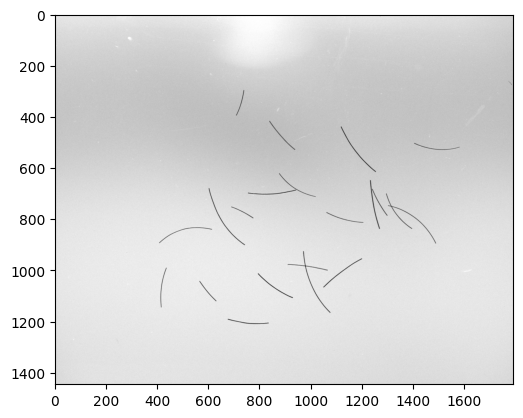

In [ ]:
# Load an image
# img = segmenter.load_image(Path("../data/curv/004_demo_curv.tiff"))
# Set an image
img = Image.open(Path("../data/real_curv/011.tiff"))
img = np.array(img.convert('L'))
height, width = 1446, 1794
img = cv2.resize(img, (width, height))

plt.imshow(img, cmap="gray")

segmenter.set_image(img)

# Simple segmentation with a point prompt
background_point = np.unravel_index(np.argmax(img), img.shape)
foreground_point = np.unravel_index(np.argmin(img), img.shape)
input_points = np.array([background_point, foreground_point])  # (x, y)
input_labels = np.array([1, 0])           # 0 means background, 1 means foreground

masks, scores, logits = segmenter.segment(
    input_points=input_points,
    input_labels=input_labels,
    multimask_output=True
)


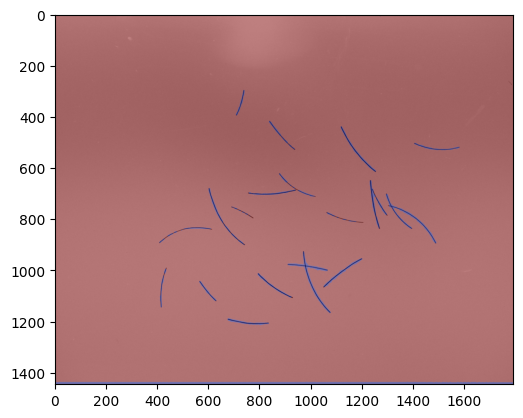

In [11]:
mask = masks[np.argmax(scores), :, :]  # Select the mask with the highest score
# Visualize result
plt.imshow(img, cmap="gray")
plt.imshow(mask, alpha=0.5, cmap='jet')
plt.show()

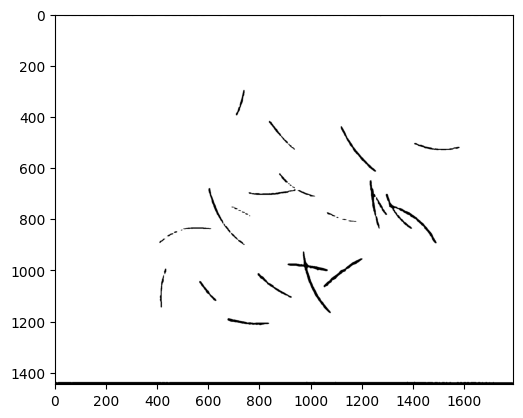

In [12]:
plt.imshow(mask, cmap='gray')